In [7]:
import pickle
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
assert RESULTS.is_dir(), RESULTS

# Filename: [randlabels_]..._seed{N}_{dataset}.pkl
FNAME = re.compile(r"^(?P<rand>randlabels_)?.*__?seed(?P<seed>\d+)_(?P<dataset>.+)\.pkl$")

def discover(results: Path):
    'Group run files by (dataset, regime).'
    cond = defaultdict(list)
    for p in sorted(results.glob("*.pkl")):
        m = FNAME.match(p.name)
        if not m:
            continue
        regime = "random" if m.group("rand") else "real"
        cond[(m.group("dataset"), regime)].append(p)
    return cond

conditions = discover(RESULTS)
print("conditions found:")
for (ds, reg), paths in sorted(conditions.items()):
    print(f"  {ds:14s} {reg:7s} {len(paths)} runs")

conditions found:
  Bioresponse    random  20 runs
  Bioresponse    real    20 runs
  CIFAR_10       random  20 runs
  CIFAR_10       real    20 runs
  Fashion-MNIST  random  20 runs
  Fashion-MNIST  real    20 runs
  mnist_784      random  20 runs
  mnist_784      real    20 runs


## 1. Load curves and final accuracies per condition

In [8]:
def load_condition(paths):
    'Return epoch_idx, acc matrix, loss matrix (inits x checkpoints), and final accs.'
    accs, losses, ftr, fte, epoch_idx = [], [], [], [], None
    for p in paths:
        d = pickle.load(open(p, "rb"))
        tr = d["trace"]
        accs.append(np.asarray(tr["acc"], float))
        losses.append(np.asarray(tr["loss"], float))
        ftr.append(d.get("final_train_acc", np.nan))
        fte.append(d.get("final_test_acc", np.nan))
        epoch_idx = np.asarray(tr["epoch_idx"], int)
    # Align to the shortest trace in case of ragged lengths.
    L = min(map(len, accs))
    acc = np.vstack([a[:L] for a in accs])
    loss = np.vstack([l[:L] for l in losses])
    return {
        "epoch": epoch_idx[:L],
        "acc": acc, "loss": loss,
        "final_train": np.array(ftr, float), "final_test": np.array(fte, float),
    }

data = {cond: load_condition(paths) for cond, paths in conditions.items()}
datasets = sorted({ds for ds, _ in data})
print("datasets:", datasets)

datasets: ['Bioresponse', 'CIFAR_10', 'Fashion-MNIST', 'mnist_784']


## 2. Final train / test accuracy and generalization gap

Per dataset and regime: mean final **train** accuracy, mean final **test** accuracy,
and the **gap** (train - test). A large gap = memorization. (Random-label test
accuracy may be NaN for runs created before test evaluation was added to the random
script.)

In [9]:
rows = []
for (ds, reg), d in sorted(data.items()):
    rows.append({
        "dataset": ds, "regime": reg,
        "train_acc": np.nanmean(d["final_train"]),
        "test_acc": np.nanmean(d["final_test"]),
        "gen_gap": np.nanmean(d["final_train"]) - np.nanmean(d["final_test"]),
        "n": len(d["final_train"]),
    })
summary = pd.DataFrame(rows)
display(summary.round(3))
summary.pivot(index="dataset", columns="regime", values=["train_acc","test_acc","gen_gap"]).round(3)

/tmp/ipykernel_1211772/820270268.py:6: RuntimeWarning: Mean of empty slice
  "test_acc": np.nanmean(d["final_test"]),
/tmp/ipykernel_1211772/820270268.py:7: RuntimeWarning: Mean of empty slice
  "gen_gap": np.nanmean(d["final_train"]) - np.nanmean(d["final_test"]),


,dataset,regime,train_acc,test_acc,gen_gap,n
0,Bioresponse,random,0.999,NaN,NaN,20
1,Bioresponse,real,1.000,0.793,0.207,20
2,CIFAR_10,random,1.000,NaN,NaN,20
3,CIFAR_10,real,1.000,0.490,0.510,20
4,Fashion-MNIST,random,0.996,NaN,NaN,20
5,Fashion-MNIST,real,1.000,0.888,0.112,20
6,mnist_784,random,0.992,NaN,NaN,20
7,mnist_784,real,1.000,0.976,0.024,20


train_acc      test_acc        gen_gap       
regime           random real   random   real  random   real
dataset                                                    
Bioresponse       0.999  1.0      NaN  0.793     NaN  0.207
CIFAR_10          1.000  1.0      NaN  0.490     NaN  0.510
Fashion-MNIST     0.996  1.0      NaN  0.888     NaN  0.112
mnist_784         0.992  1.0      NaN  0.976     NaN  0.024

## 3. Training-accuracy curves (the optimization process)

Mean training accuracy across inits (band = min-max envelope), real vs random, per
dataset. The dashed horizontal line marks the mean **final test** accuracy of the
*real* runs -- the gap between the real training curve and that line is the
generalization gap visualised.

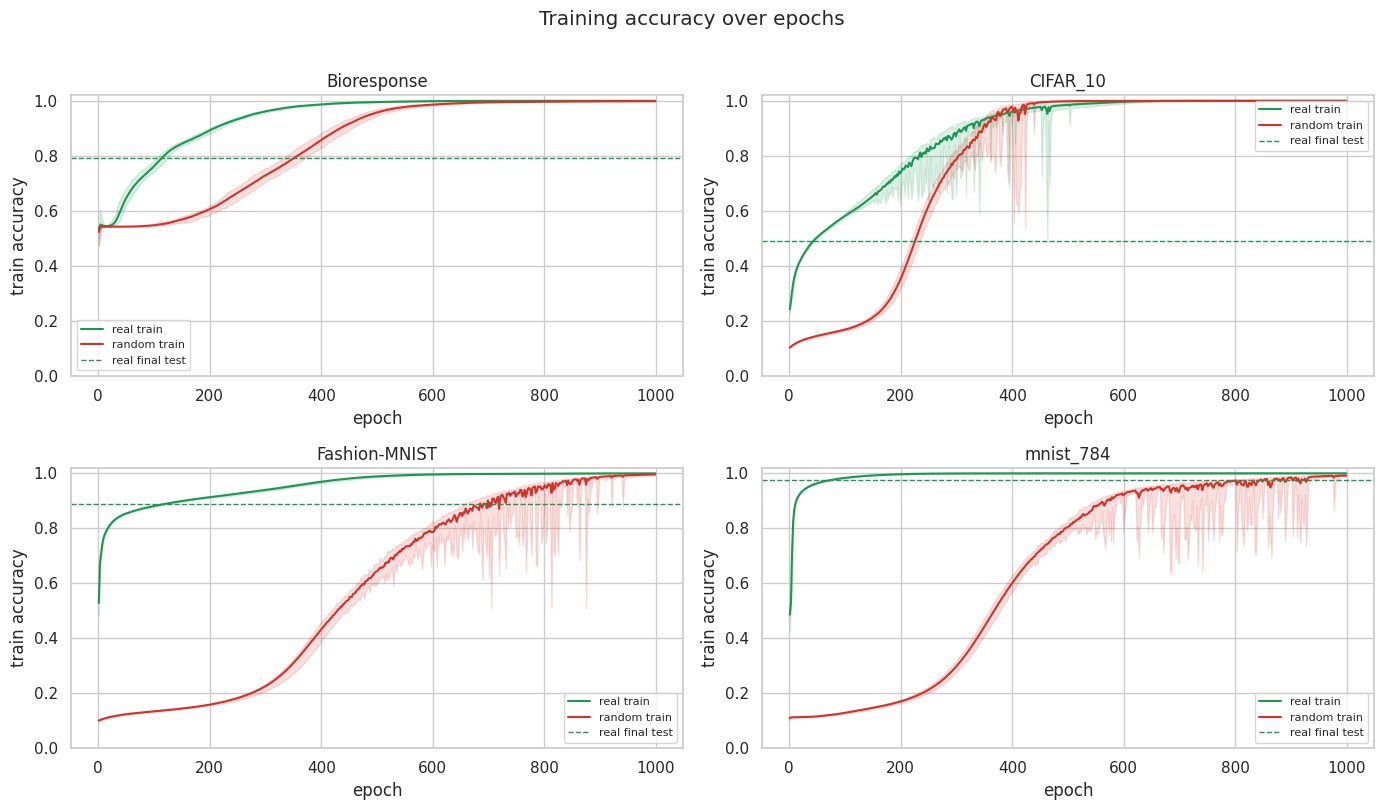

In [10]:
ncol = 2
nrow = int(np.ceil(len(datasets) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7*ncol, 4*nrow), squeeze=False)
colors = {"real": "#1a9850", "random": "#d73027"}
for ax, ds in zip(axes.ravel(), datasets):
    for reg in ("real", "random"):
        d = data.get((ds, reg))
        if d is None:
            continue
        x = d["epoch"]; m = d["acc"].mean(0)
        ax.plot(x, m, color=colors[reg], label=f"{reg} train")
        ax.fill_between(x, d["acc"].min(0), d["acc"].max(0), color=colors[reg], alpha=0.15)
    dr = data.get((ds, "real"))
    if dr is not None and np.isfinite(np.nanmean(dr["final_test"])):
        ax.axhline(np.nanmean(dr["final_test"]), ls="--", color=colors["real"], lw=1,
                   label="real final test")
    ax.set(title=ds, xlabel="epoch", ylabel="train accuracy", ylim=(0, 1.02))
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(datasets):]:
    ax.axis("off")
fig.suptitle("Training accuracy over epochs", y=1.01); plt.tight_layout(); plt.show()

## 4. Training-loss curves

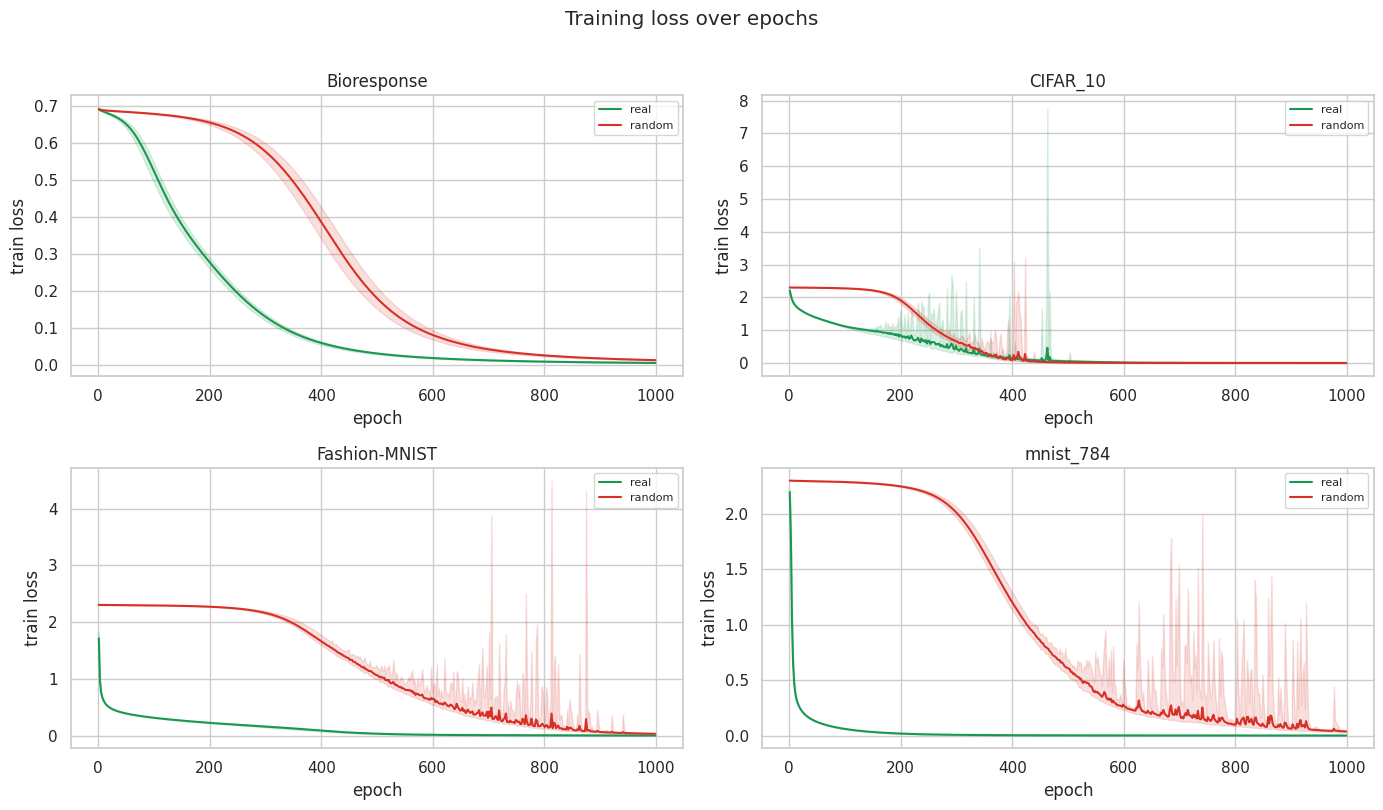

In [11]:
fig, axes = plt.subplots(nrow, ncol, figsize=(7*ncol, 4*nrow), squeeze=False)
for ax, ds in zip(axes.ravel(), datasets):
    for reg in ("real", "random"):
        d = data.get((ds, reg))
        if d is None:
            continue
        x = d["epoch"]; m = d["loss"].mean(0)
        ax.plot(x, m, color=colors[reg], label=f"{reg}")
        ax.fill_between(x, d["loss"].min(0), d["loss"].max(0), color=colors[reg], alpha=0.15)
    ax.set(title=ds, xlabel="epoch", ylabel="train loss")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(datasets):]:
    ax.axis("off")
fig.suptitle("Training loss over epochs", y=1.01); plt.tight_layout(); plt.show()

## 5. Reading it

- **Both regimes drive train accuracy to ~1.0** on every dataset -- that's expected;
  a big-enough MLP memorizes random labels (Zhang et al.). The optimization *process*
  (how fast, how monotone, how variable across inits) is what differs.
- **The discriminating quantity is the real-regime test accuracy / generalization
  gap** in the summary table. A dataset whose *real* runs reach high train **and**
  high test accuracy is a true generalizing-vs-memorizing contrast; one whose real
  runs reach high train but **low test** accuracy is memorizing even on real labels,
  so its "real" STN is not really a generalizing regime -- explaining why such a
  dataset behaves as an outlier in the STN comparisons.